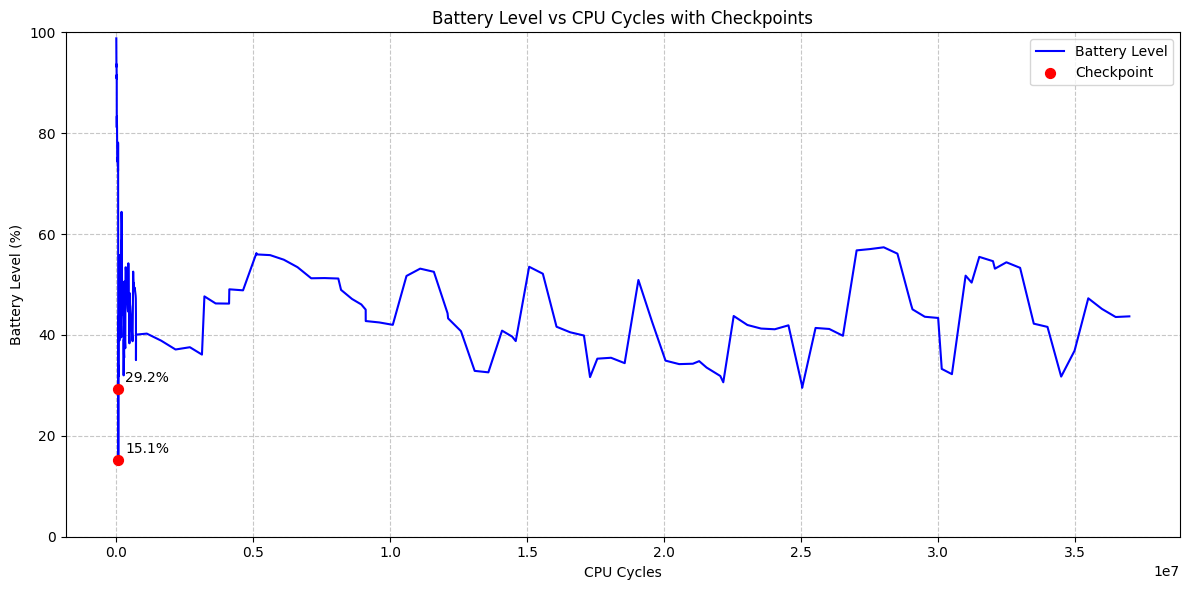

Total checkpoints: 2
Battery level range: 15.14% to 98.81%
CPU cycles range: 9 to 36997951


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV data
data = pd.read_csv('battery_drain_log.csv')

# Create a figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot the battery level vs CPU cycles
plt.plot(data['CPUCycles'], data['BatteryLevel'], 'b-', label='Battery Level')

# Find and highlight the checkpoint points
checkpoint_data = data[data['Checkpoint'] == True]
plt.scatter(checkpoint_data['CPUCycles'], checkpoint_data['BatteryLevel'], 
            color='red', s=50, label='Checkpoint', zorder=5)

# Add labels and title
plt.xlabel('CPU Cycles')
plt.ylabel('Battery Level (%)')
plt.title('Battery Level vs CPU Cycles with Checkpoints')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Format the y-axis to show percentages
plt.ylim(min(0, data['BatteryLevel'].min()), 100)

# Add annotations for better readability
for _, point in checkpoint_data.iterrows():
    plt.annotate(f"{point['BatteryLevel']:.1f}%", 
                 (point['CPUCycles'], point['BatteryLevel']),
                 xytext=(5, 5), textcoords='offset points')

# Show the plot
plt.tight_layout()
plt.show()

# Display some statistics
print(f"Total checkpoints: {len(checkpoint_data)}")
print(f"Battery level range: {data['BatteryLevel'].min():.2f}% to {data['BatteryLevel'].max():.2f}%")
print(f"CPU cycles range: {data['CPUCycles'].min()} to {data['CPUCycles'].max()}")

In [3]:
!pip install matplotlib

     |████████████████████████████████| 9.2 MB 1.5 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 9.3 MB/s eta 0:00:01
     |████████████████████████████████| 104 kB 8.9 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 6.1 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 168 kB/s eta 0:00:01


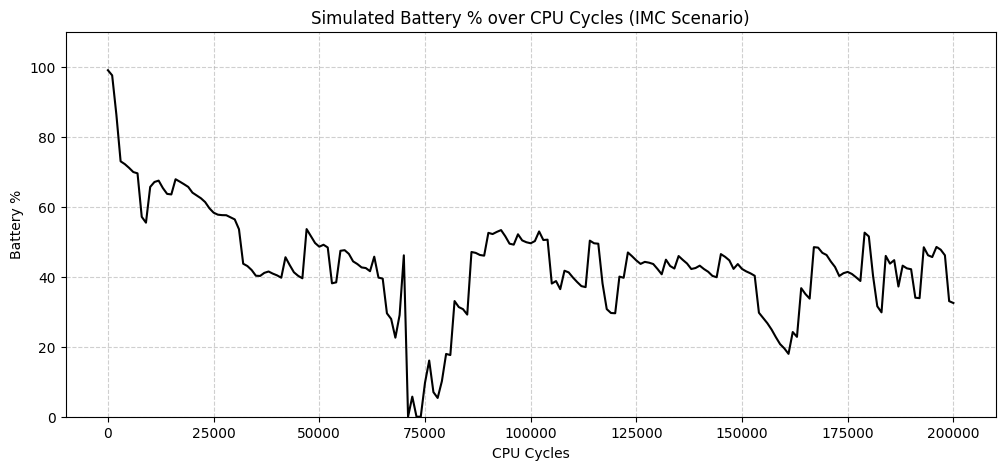

In [14]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt

# Cell 2: Battery Simulation Function
def simulate_imc_battery(cycles=200000, step=1000, seed=42):
    np.random.seed(seed)
    x = np.arange(0, cycles + 1, step)
    battery = np.zeros_like(x, dtype=float)
    battery[0] = 99  # Start from near full charge

    failure_triggered = False  # Ensure one full drop

    for i in range(1, len(x)):
        decay = np.random.uniform(0.2, 1.5)

        # Force one big drop (simulate failure)
        if not failure_triggered and 70000 < x[i] < 100000:
            decay += np.random.uniform(50, 80)
            failure_triggered = True

        elif np.random.rand() < 0.08:
            decay += np.random.uniform(5, 12)

        # Recharge rules
        if battery[i - 1] < 40 and np.random.rand() < 0.3:
            recharge = np.random.uniform(5, 20)
        elif np.random.rand() < 0.08:
            recharge = np.random.uniform(2, 10)
        else:
            recharge = 0

        battery[i] = battery[i - 1] - decay + recharge + np.random.normal(0, 0.7)

        # Clamp to 0–100 (we allow 0 now for failure)
        battery[i] = min(max(battery[i], 0), 100)

    return x, battery


# Cell 3: Plotting
def plot_battery(cycles=200000, step=1000):
    x, battery = simulate_imc_battery(cycles, step)
    plt.figure(figsize=(12, 5))
    plt.plot(x, battery, color='black')
    plt.title("Simulated Battery % over CPU Cycles (IMC Scenario)")
    plt.xlabel("CPU Cycles")
    plt.ylabel("Battery %")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 110)
    plt.show()

# Cell 4: Run Simulation
plot_battery()
